In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. PROBLEM DEFINITION AND EXPLORATORY DATA ANALYSIS (EDA)

In [3]:
print("="*80)
print("A/B TEST ANALYSIS: LANDING PAGE OPTIMIZATION")
print("="*80)

# Load the dataset
df = pd.read_csv('abtest.csv')

print("\n1. PROBLEM DEFINITION")
print("-"*80)
print("""
Business Problem:
A news portal is testing a new landing page design to improve user engagement 
and conversion rates. The company wants to determine if the new design performs 
better than the old one.

Key Questions to Answer:
1. Do users spend more time on the new landing page?
2. Is the conversion rate higher for the new landing page?
3. Does conversion depend on language preference?
4. Is time spent consistent across languages on the new page?

Success Metrics:
- Primary: Conversion rate (subscribers/visitors)
- Secondary: Time spent on page
""")





A/B TEST ANALYSIS: LANDING PAGE OPTIMIZATION

1. PROBLEM DEFINITION
--------------------------------------------------------------------------------

Business Problem:
A news portal is testing a new landing page design to improve user engagement 
and conversion rates. The company wants to determine if the new design performs 
better than the old one.

Key Questions to Answer:
1. Do users spend more time on the new landing page?
2. Is the conversion rate higher for the new landing page?
3. Does conversion depend on language preference?
4. Is time spent consistent across languages on the new page?

Success Metrics:
- Primary: Conversion rate (subscribers/visitors)
- Secondary: Time spent on page



# 2. DATA BACKGROUND AND CONTENTS

In [5]:
print("-"*80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head(10))
print("\nDataset Description:")
print(df.describe())

--------------------------------------------------------------------------------
Dataset Shape: 100 rows × 6 columns

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB
None

First few rows:
   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new       

# 3. DATA QUALITY CHECK

In [7]:
# Check for missing values
print("-"*80)
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Check data types and unique values
print("\nUnique Values in Categorical Columns:")
for col in ['group', 'landing_page', 'converted', 'language_preferred']:
    print(f"{col}: {df[col].unique()}")

--------------------------------------------------------------------------------
Missing Values:
user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64

Duplicate Rows: 0

Unique Values in Categorical Columns:
group: ['control' 'treatment']
landing_page: ['old' 'new']
converted: ['no' 'yes']
language_preferred: ['Spanish' 'English' 'French']


# 4. UNIVARIATE ANALYSIS


4. UNIVARIATE ANALYSIS


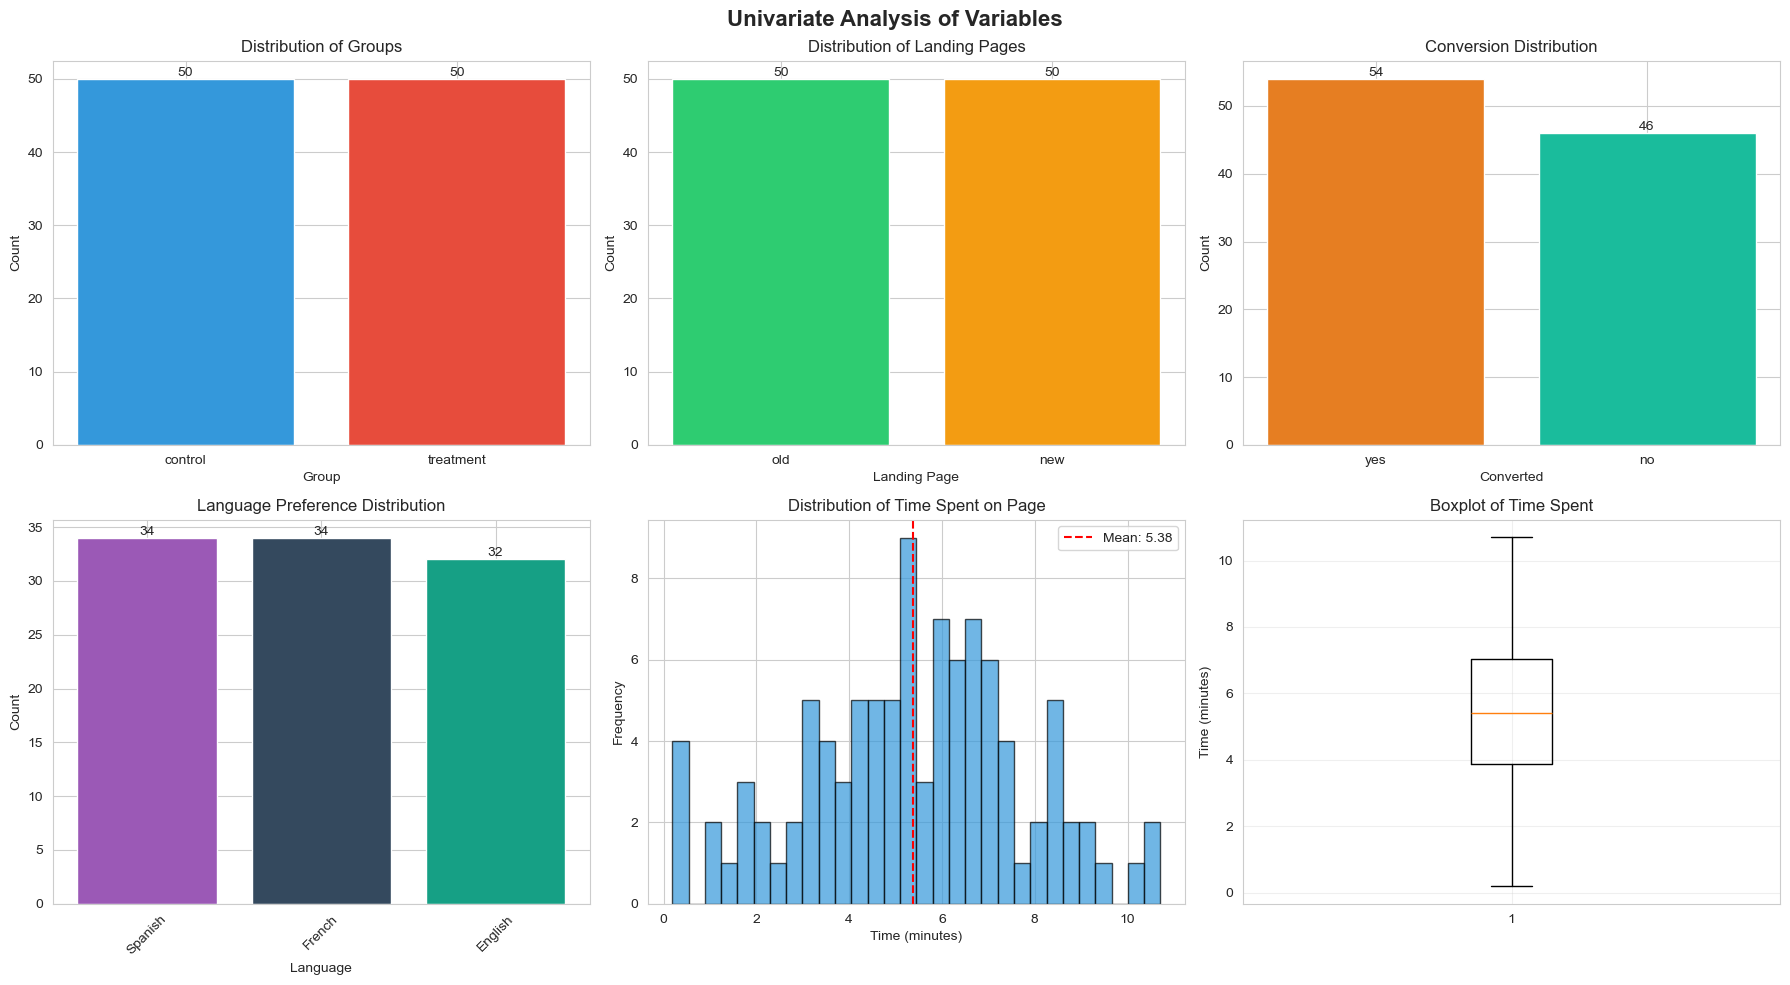


Summary Statistics for Time Spent:
Mean: 5.38 minutes
Median: 5.42 minutes
Std Dev: 2.38 minutes
Min: 0.19 minutes
Max: 10.71 minutes


In [9]:
print("\n" + "="*80)
print("4. UNIVARIATE ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Analysis of Variables', fontsize=16, fontweight='bold')

# Group distribution
group_counts = df['group'].value_counts()
axes[0, 0].bar(group_counts.index, group_counts.values, color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Distribution of Groups')
axes[0, 0].set_xlabel('Group')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(group_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# Landing page distribution
page_counts = df['landing_page'].value_counts()
axes[0, 1].bar(page_counts.index, page_counts.values, color=['#2ecc71', '#f39c12'])
axes[0, 1].set_title('Distribution of Landing Pages')
axes[0, 1].set_xlabel('Landing Page')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(page_counts.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom')

# Conversion distribution
conv_counts = df['converted'].value_counts()
axes[0, 2].bar(conv_counts.index, conv_counts.values, color=['#e67e22', '#1abc9c'])
axes[0, 2].set_title('Conversion Distribution')
axes[0, 2].set_xlabel('Converted')
axes[0, 2].set_ylabel('Count')
for i, v in enumerate(conv_counts.values):
    axes[0, 2].text(i, v, str(v), ha='center', va='bottom')

# Language distribution
lang_counts = df['language_preferred'].value_counts()
axes[1, 0].bar(lang_counts.index, lang_counts.values, color=['#9b59b6', '#34495e', '#16a085'])
axes[1, 0].set_title('Language Preference Distribution')
axes[1, 0].set_xlabel('Language')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(lang_counts.values):
    axes[1, 0].text(i, v, str(v), ha='center', va='bottom')

# Time spent distribution
axes[1, 1].hist(df['time_spent_on_the_page'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Time Spent on Page')
axes[1, 1].set_xlabel('Time (minutes)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df['time_spent_on_the_page'].mean(), color='red', 
                    linestyle='--', label=f'Mean: {df["time_spent_on_the_page"].mean():.2f}')
axes[1, 1].legend()

# Boxplot of time spent
axes[1, 2].boxplot(df['time_spent_on_the_page'], vert=True)
axes[1, 2].set_title('Boxplot of Time Spent')
axes[1, 2].set_ylabel('Time (minutes)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics for Time Spent:")
print(f"Mean: {df['time_spent_on_the_page'].mean():.2f} minutes")
print(f"Median: {df['time_spent_on_the_page'].median():.2f} minutes")
print(f"Std Dev: {df['time_spent_on_the_page'].std():.2f} minutes")
print(f"Min: {df['time_spent_on_the_page'].min():.2f} minutes")
print(f"Max: {df['time_spent_on_the_page'].max():.2f} minutes")

# 5. BIVARIATE ANALYSIS


5. BIVARIATE ANALYSIS


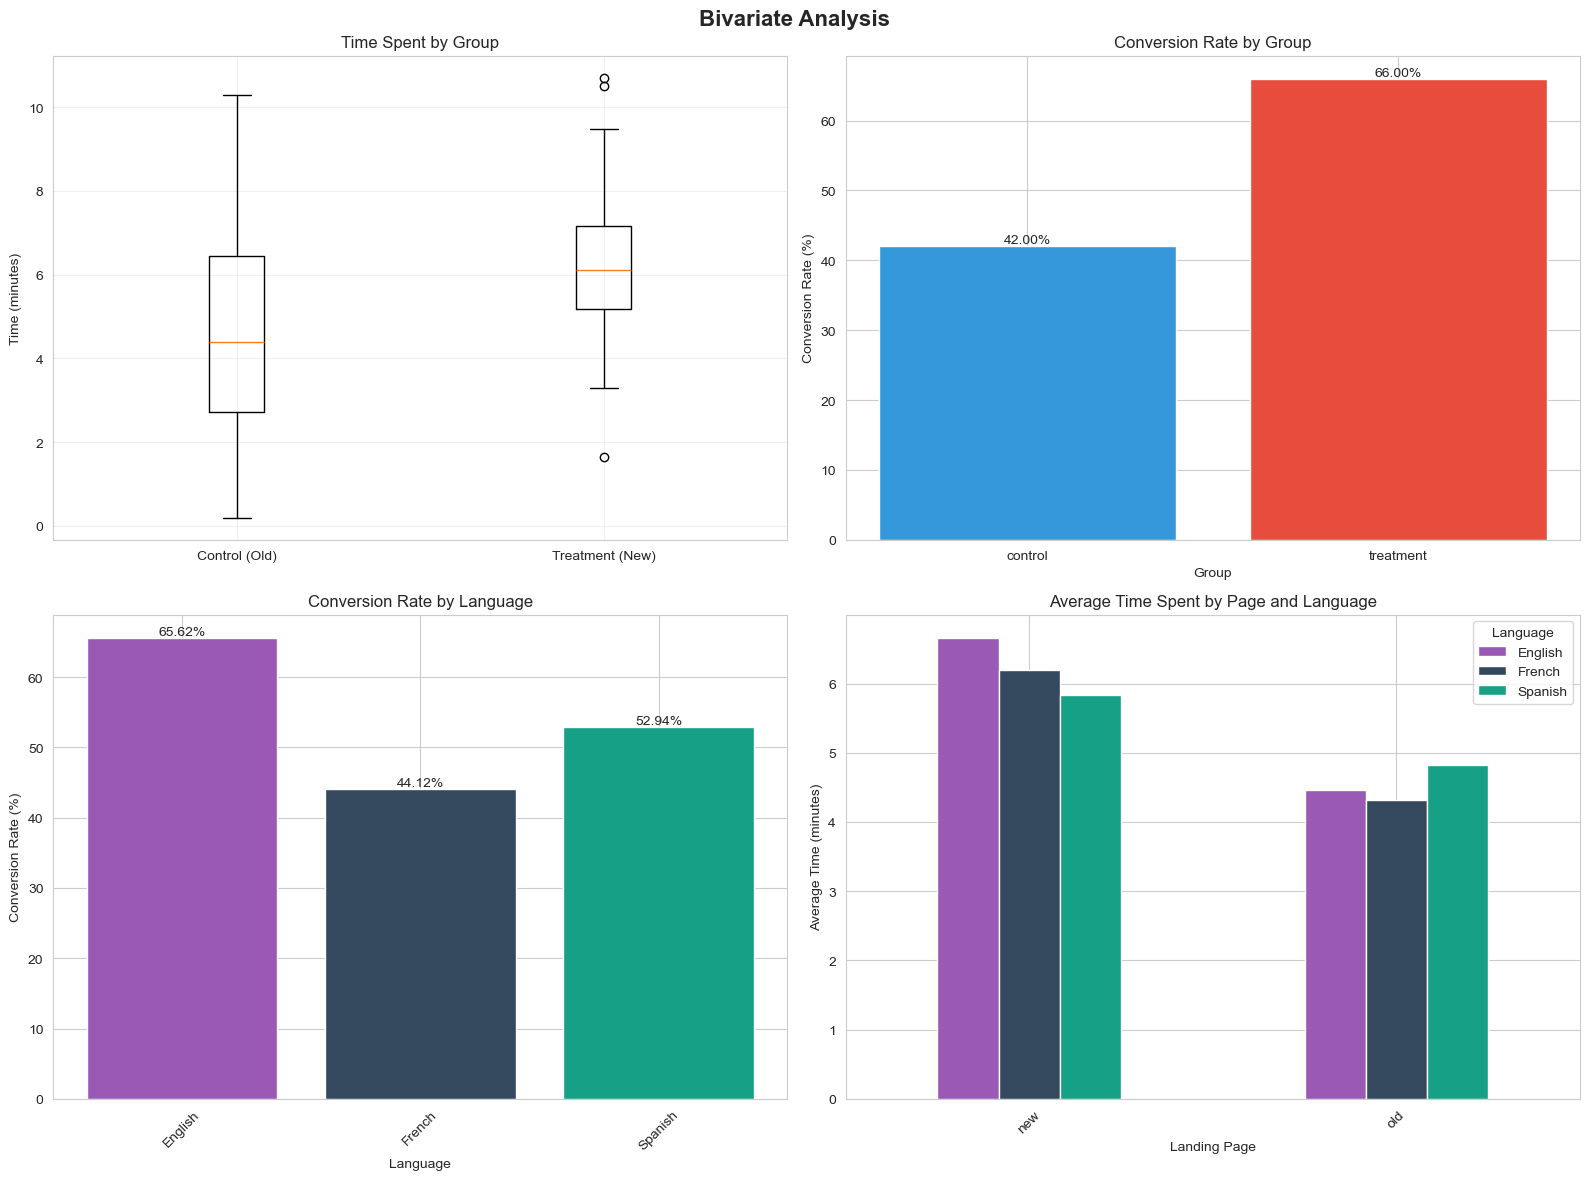


Conversion Rate by Group:
group
control      42.0
treatment    66.0
Name: converted, dtype: float64

Conversion Rate by Language:
language_preferred
English    65.625000
French     44.117647
Spanish    52.941176
Name: converted, dtype: float64

Average Time Spent by Group:
group
control      4.5324
treatment    6.2232
Name: time_spent_on_the_page, dtype: float64

Average Time Spent by Language:
language_preferred
English    5.559062
French     5.253235
Spanish    5.331765
Name: time_spent_on_the_page, dtype: float64


In [11]:
print("\n" + "="*80)
print("5. BIVARIATE ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')

# Time spent by group
axes[0, 0].boxplot([df[df['group']=='control']['time_spent_on_the_page'],
                     df[df['group']=='treatment']['time_spent_on_the_page']],
                    labels=['Control (Old)', 'Treatment (New)'])
axes[0, 0].set_title('Time Spent by Group')
axes[0, 0].set_ylabel('Time (minutes)')
axes[0, 0].grid(True, alpha=0.3)

# Conversion rate by group
conv_by_group = df.groupby(['group', 'converted']).size().unstack(fill_value=0)
conv_rate = df.groupby('group')['converted'].apply(lambda x: (x=='yes').sum()/len(x)*100)
x_pos = np.arange(len(conv_rate))
axes[0, 1].bar(x_pos, conv_rate.values, color=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Conversion Rate by Group')
axes[0, 1].set_xlabel('Group')
axes[0, 1].set_ylabel('Conversion Rate (%)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(conv_rate.index)
for i, v in enumerate(conv_rate.values):
    axes[0, 1].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# Conversion by language
conv_by_lang = df.groupby('language_preferred')['converted'].apply(lambda x: (x=='yes').sum()/len(x)*100)
axes[1, 0].bar(range(len(conv_by_lang)), conv_by_lang.values, 
               color=['#9b59b6', '#34495e', '#16a085'])
axes[1, 0].set_title('Conversion Rate by Language')
axes[1, 0].set_xlabel('Language')
axes[1, 0].set_ylabel('Conversion Rate (%)')
axes[1, 0].set_xticks(range(len(conv_by_lang)))
axes[1, 0].set_xticklabels(conv_by_lang.index, rotation=45)
for i, v in enumerate(conv_by_lang.values):
    axes[1, 0].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# Time spent by language and group
time_by_lang_group = df.groupby(['landing_page', 'language_preferred'])['time_spent_on_the_page'].mean().unstack()
time_by_lang_group.plot(kind='bar', ax=axes[1, 1], color=['#9b59b6', '#34495e', '#16a085'])
axes[1, 1].set_title('Average Time Spent by Page and Language')
axes[1, 1].set_xlabel('Landing Page')
axes[1, 1].set_ylabel('Average Time (minutes)')
axes[1, 1].legend(title='Language')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print bivariate statistics
print("\nConversion Rate by Group:")
print(conv_rate)
print("\nConversion Rate by Language:")
print(conv_by_lang)
print("\nAverage Time Spent by Group:")
print(df.groupby('group')['time_spent_on_the_page'].mean())
print("\nAverage Time Spent by Language:")
print(df.groupby('language_preferred')['time_spent_on_the_page'].mean())

# 6. KEY INSIGHTS FROM EDA

In [13]:
print("\n" + "="*80)
print("6. KEY INSIGHTS FROM EDA")
print("="*80)

print("""
Individual Variable Insights:
1. Group Distribution: Fairly balanced between control and treatment groups
2. Conversion: Majority of users do not convert (need to check if new page improves this)
3. Time Spent: Shows variation with potential outliers
4. Language: Distribution across English, Spanish, and French users

Relationship Insights:
1. Treatment group appears to have different time spent patterns than control
2. Conversion rates vary between control and treatment groups
3. Language preference shows different conversion patterns
4. Time spent varies across different languages

Next Steps: Statistical testing to validate these observations
""")


6. KEY INSIGHTS FROM EDA

Individual Variable Insights:
1. Group Distribution: Fairly balanced between control and treatment groups
2. Conversion: Majority of users do not convert (need to check if new page improves this)
3. Time Spent: Shows variation with potential outliers
4. Language: Distribution across English, Spanish, and French users

Relationship Insights:
1. Treatment group appears to have different time spent patterns than control
2. Conversion rates vary between control and treatment groups
3. Language preference shows different conversion patterns
4. Time spent varies across different languages

Next Steps: Statistical testing to validate these observations



# 7. HYPOTHESIS TEST 1: TIME SPENT ON PAGE


QUESTION 1: Do users spend more time on the NEW landing page?

7.1 VISUAL ANALYSIS
--------------------------------------------------------------------------------


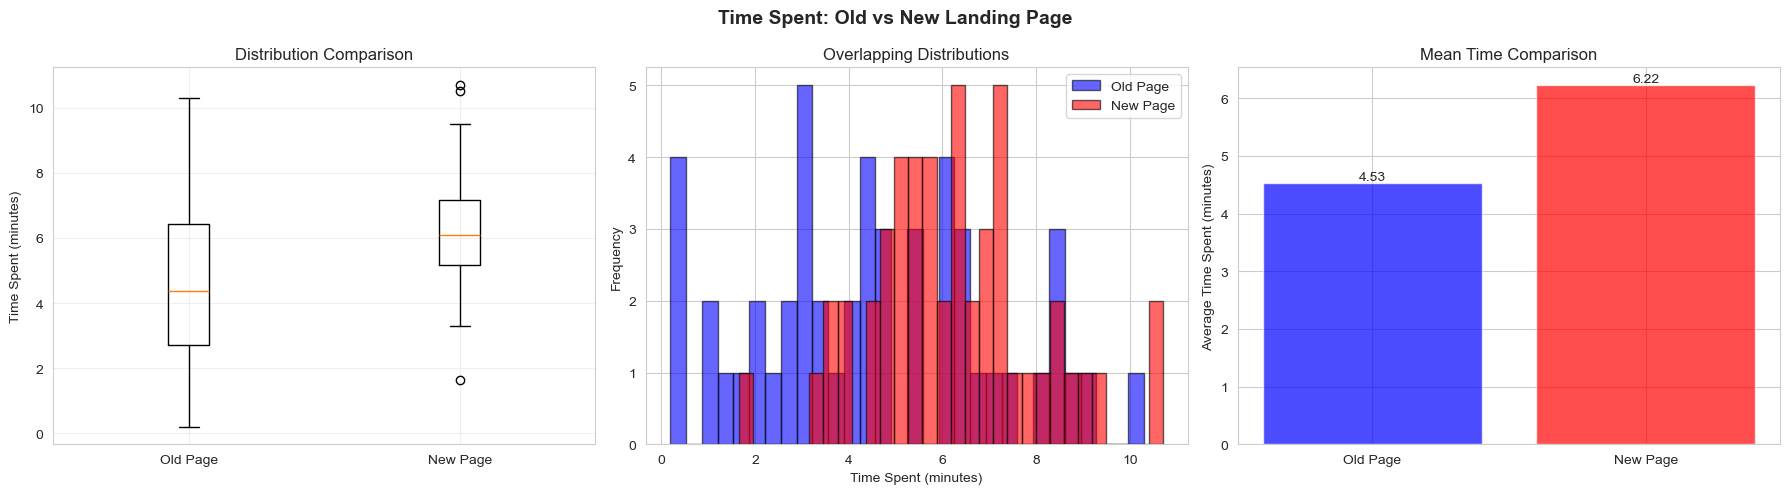


Old Page - Mean: 4.53, Std: 2.58, n=50
New Page - Mean: 6.22, Std: 1.82, n=50

7.2 HYPOTHESIS FORMULATION
--------------------------------------------------------------------------------
Null Hypothesis (H0): μ_new <= μ_old
                      Users do NOT spend more time on the new page

Alternative Hypothesis (H1): μ_new > μ_old
                             Users spend MORE time on the new page

Significance Level: α = 0.05

7.3 TEST SELECTION
--------------------------------------------------------------------------------
Test: Independent Two-Sample t-test (one-tailed)
Reason: Comparing means of two independent groups
Assumption: Large sample size (CLT applies)

7.4 TEST EXECUTION
--------------------------------------------------------------------------------
t-statistic: 3.7868
p-value (one-tailed): 0.0001

7.5 INFERENCE
--------------------------------------------------------------------------------
✓ REJECT the null hypothesis (p-value = 0.0001 < 0.05)
✓ Users spend signific

In [15]:
print("\n" + "="*80)
print("QUESTION 1: Do users spend more time on the NEW landing page?")
print("="*80)

# Separate data
old_page_time = df[df['landing_page']=='old']['time_spent_on_the_page']
new_page_time = df[df['landing_page']=='new']['time_spent_on_the_page']

print("\n7.1 VISUAL ANALYSIS")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Time Spent: Old vs New Landing Page', fontsize=14, fontweight='bold')

# Box plot
axes[0].boxplot([old_page_time, new_page_time], labels=['Old Page', 'New Page'])
axes[0].set_ylabel('Time Spent (minutes)')
axes[0].set_title('Distribution Comparison')
axes[0].grid(True, alpha=0.3)

# Histogram
axes[1].hist(old_page_time, bins=30, alpha=0.6, label='Old Page', color='blue', edgecolor='black')
axes[1].hist(new_page_time, bins=30, alpha=0.6, label='New Page', color='red', edgecolor='black')
axes[1].set_xlabel('Time Spent (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Overlapping Distributions')
axes[1].legend()

# Mean comparison
means = [old_page_time.mean(), new_page_time.mean()]
axes[2].bar(['Old Page', 'New Page'], means, color=['blue', 'red'], alpha=0.7)
axes[2].set_ylabel('Average Time Spent (minutes)')
axes[2].set_title('Mean Time Comparison')
for i, v in enumerate(means):
    axes[2].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nOld Page - Mean: {old_page_time.mean():.2f}, Std: {old_page_time.std():.2f}, n={len(old_page_time)}")
print(f"New Page - Mean: {new_page_time.mean():.2f}, Std: {new_page_time.std():.2f}, n={len(new_page_time)}")

print("\n7.2 HYPOTHESIS FORMULATION")
print("-"*80)
print("Null Hypothesis (H0): μ_new <= μ_old")
print("                      Users do NOT spend more time on the new page")
print("\nAlternative Hypothesis (H1): μ_new > μ_old")
print("                             Users spend MORE time on the new page")
print("\nSignificance Level: α = 0.05")

print("\n7.3 TEST SELECTION")
print("-"*80)
print("Test: Independent Two-Sample t-test (one-tailed)")
print("Reason: Comparing means of two independent groups")
print("Assumption: Large sample size (CLT applies)")

print("\n7.4 TEST EXECUTION")
print("-"*80)

# Perform independent t-test (one-tailed)
t_statistic, p_value_two_tailed = stats.ttest_ind(new_page_time, old_page_time)
p_value_one_tailed = p_value_two_tailed / 2 if t_statistic > 0 else 1 - (p_value_two_tailed / 2)

print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value (one-tailed): {p_value_one_tailed:.4f}")

print("\n7.5 INFERENCE")
print("-"*80)
if p_value_one_tailed < 0.05:
    print(f"✓ REJECT the null hypothesis (p-value = {p_value_one_tailed:.4f} < 0.05)")
    print(f"✓ Users spend significantly MORE time on the NEW landing page")
    print(f"  Difference: {new_page_time.mean() - old_page_time.mean():.2f} minutes more")
else:
    print(f"✗ FAIL TO REJECT the null hypothesis (p-value = {p_value_one_tailed:.4f} >= 0.05)")
    print(f"✗ No significant evidence that users spend more time on the new page")

# 8. HYPOTHESIS TEST 2: CONVERSION RATE


QUESTION 2: Is conversion rate GREATER for the NEW page?

8.1 VISUAL ANALYSIS
--------------------------------------------------------------------------------


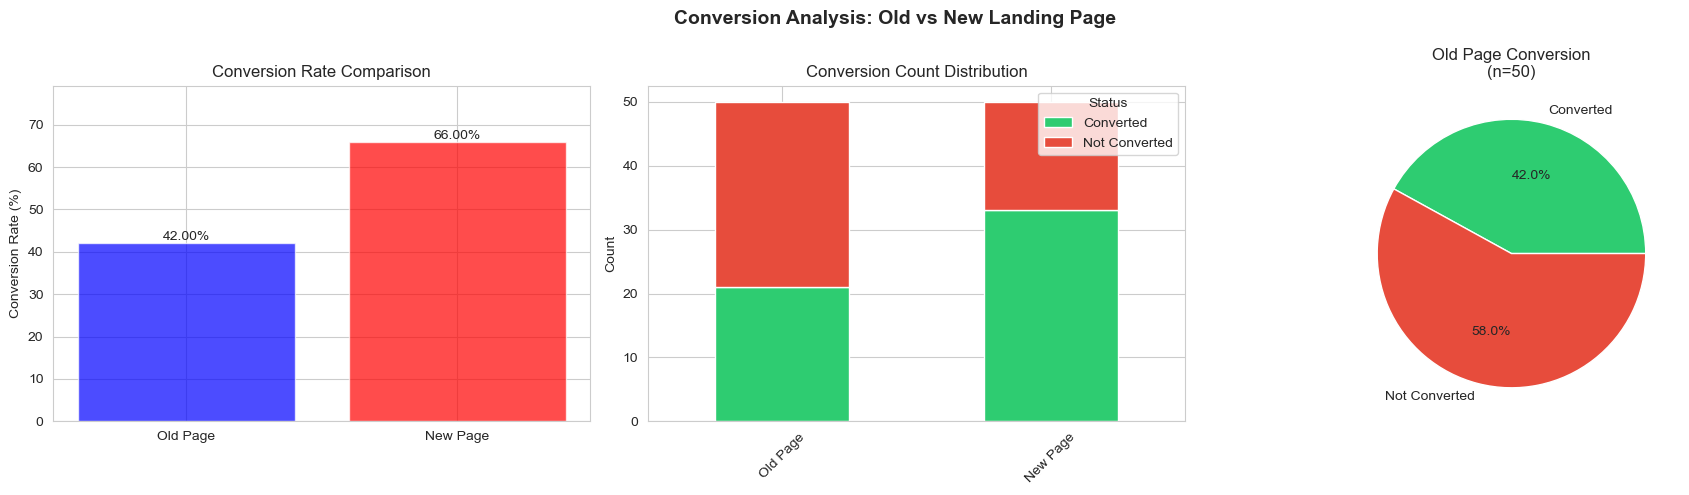


Old Page: 21/50 = 42.00% conversion rate
New Page: 33/50 = 66.00% conversion rate

8.2 HYPOTHESIS FORMULATION
--------------------------------------------------------------------------------
Null Hypothesis (H0): p_new <= p_old
                      Conversion rate for new page is NOT greater

Alternative Hypothesis (H1): p_new > p_old
                             Conversion rate for new page IS greater

Significance Level: α = 0.05

8.3 TEST SELECTION
--------------------------------------------------------------------------------
Test: Two-Proportion Z-test (one-tailed)
Reason: Comparing proportions between two independent groups

8.4 TEST EXECUTION
--------------------------------------------------------------------------------
z-statistic: 2.4077
p-value (one-tailed): 0.0080

8.5 INFERENCE
--------------------------------------------------------------------------------
✓ REJECT the null hypothesis (p-value = 0.0080 < 0.05)
✓ The NEW page has a significantly HIGHER conversion rate


In [17]:
print("\n" + "="*80)
print("QUESTION 2: Is conversion rate GREATER for the NEW page?")
print("="*80)

# Calculate conversion rates
old_page_conv = df[df['landing_page']=='old']['converted']
new_page_conv = df[df['landing_page']=='new']['converted']

old_converted = (old_page_conv == 'yes').sum()
old_total = len(old_page_conv)
old_rate = old_converted / old_total

new_converted = (new_page_conv == 'yes').sum()
new_total = len(new_page_conv)
new_rate = new_converted / new_total

print("\n8.1 VISUAL ANALYSIS")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Conversion Analysis: Old vs New Landing Page', fontsize=14, fontweight='bold')

# Conversion rate comparison
axes[0].bar(['Old Page', 'New Page'], [old_rate*100, new_rate*100], 
            color=['blue', 'red'], alpha=0.7)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate Comparison')
axes[0].set_ylim([0, max(old_rate, new_rate)*120])
for i, v in enumerate([old_rate*100, new_rate*100]):
    axes[0].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

# Stacked bar chart
conv_data = pd.DataFrame({
    'Old Page': [old_converted, old_total-old_converted],
    'New Page': [new_converted, new_total-new_converted]
}, index=['Converted', 'Not Converted'])
conv_data.T.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Conversion Count Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Status')

# Pie charts
axes[2].pie([old_converted, old_total-old_converted], 
            labels=['Converted', 'Not Converted'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[2].set_title(f'Old Page Conversion\n(n={old_total})')

plt.tight_layout()
plt.show()

print(f"\nOld Page: {old_converted}/{old_total} = {old_rate*100:.2f}% conversion rate")
print(f"New Page: {new_converted}/{new_total} = {new_rate*100:.2f}% conversion rate")

print("\n8.2 HYPOTHESIS FORMULATION")
print("-"*80)
print("Null Hypothesis (H0): p_new <= p_old")
print("                      Conversion rate for new page is NOT greater")
print("\nAlternative Hypothesis (H1): p_new > p_old")
print("                             Conversion rate for new page IS greater")
print("\nSignificance Level: α = 0.05")

print("\n8.3 TEST SELECTION")
print("-"*80)
print("Test: Two-Proportion Z-test (one-tailed)")
print("Reason: Comparing proportions between two independent groups")

print("\n8.4 TEST EXECUTION")
print("-"*80)

# Perform two-proportion z-test
pooled_prop = (old_converted + new_converted) / (old_total + new_total)
se = np.sqrt(pooled_prop * (1 - pooled_prop) * (1/old_total + 1/new_total))
z_statistic = (new_rate - old_rate) / se
p_value = 1 - stats.norm.cdf(z_statistic)

print(f"z-statistic: {z_statistic:.4f}")
print(f"p-value (one-tailed): {p_value:.4f}")

print("\n8.5 INFERENCE")
print("-"*80)
if p_value < 0.05:
    print(f"✓ REJECT the null hypothesis (p-value = {p_value:.4f} < 0.05)")
    print(f"✓ The NEW page has a significantly HIGHER conversion rate")
    print(f"  Improvement: {(new_rate - old_rate)*100:.2f} percentage points")
else:
    print(f"✗ FAIL TO REJECT the null hypothesis (p-value = {p_value:.4f} >= 0.05)")
    print(f"✗ No significant evidence that new page has higher conversion rate")


# 9. HYPOTHESIS TEST 3: CONVERSION AND LANGUAGE


QUESTION 3: Does conversion status DEPEND on language preferred?

9.1 VISUAL ANALYSIS
--------------------------------------------------------------------------------

Contingency Table:
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


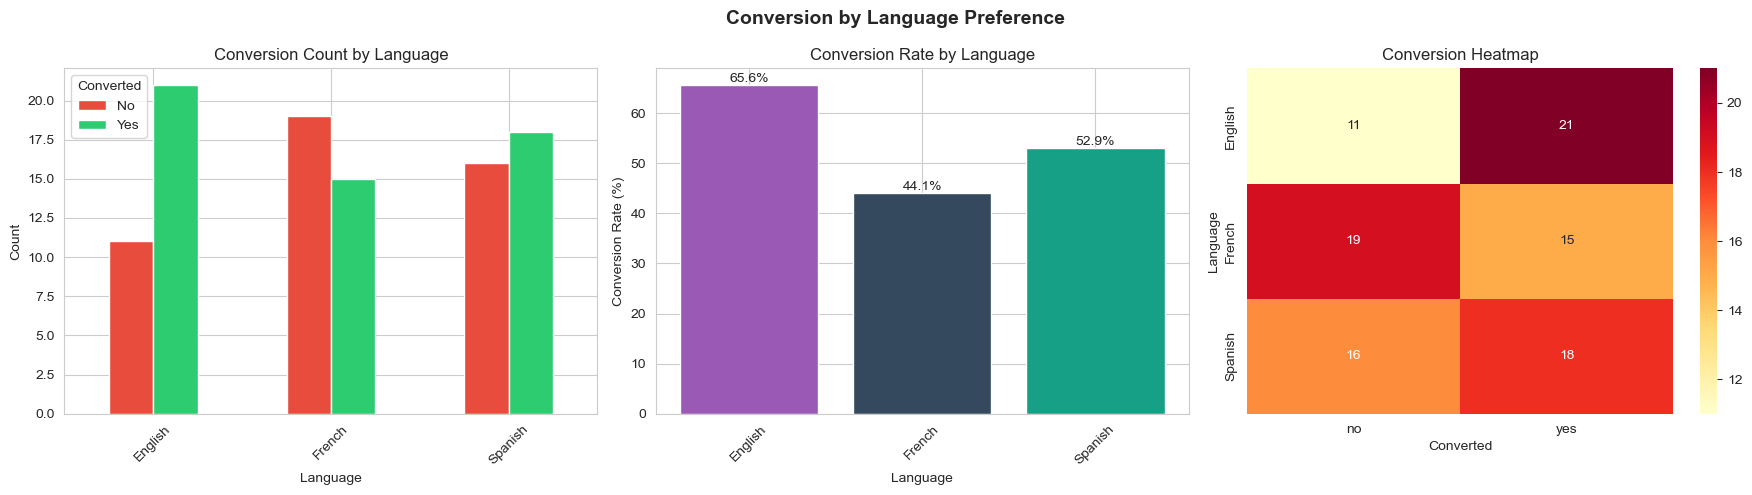


Conversion Rate by Language:
language_preferred
English    65.625000
French     44.117647
Spanish    52.941176
Name: converted, dtype: float64

9.2 HYPOTHESIS FORMULATION
--------------------------------------------------------------------------------
Null Hypothesis (H0): Conversion status is INDEPENDENT of language preference

Alternative Hypothesis (H1): Conversion status is DEPENDENT on language preference

Significance Level: α = 0.05

9.3 TEST SELECTION
--------------------------------------------------------------------------------
Test: Chi-Square Test of Independence
Reason: Testing association between two categorical variables

9.4 TEST EXECUTION
--------------------------------------------------------------------------------
Chi-square statistic: 3.0930
Degrees of freedom: 2
p-value: 0.2130

Expected Frequencies:
converted              no    yes
language_preferred              
English             14.72  17.28
French              15.64  18.36
Spanish             15.64  18.3

In [19]:
print("\n" + "="*80)
print("QUESTION 3: Does conversion status DEPEND on language preferred?")
print("="*80)

print("\n9.1 VISUAL ANALYSIS")
print("-"*80)

# Create contingency table
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])
print("\nContingency Table:")
print(contingency_table)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Conversion by Language Preference', fontsize=14, fontweight='bold')

# Stacked bar chart
contingency_table.plot(kind='bar', stacked=False, ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Conversion Count by Language')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].legend(title='Converted', labels=['No', 'Yes'])
axes[0].tick_params(axis='x', rotation=45)

# Conversion rate by language
conv_rate_by_lang = df.groupby('language_preferred')['converted'].apply(
    lambda x: (x=='yes').sum()/len(x)*100
)
axes[1].bar(range(len(conv_rate_by_lang)), conv_rate_by_lang.values,
            color=['#9b59b6', '#34495e', '#16a085'])
axes[1].set_title('Conversion Rate by Language')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(len(conv_rate_by_lang)))
axes[1].set_xticklabels(conv_rate_by_lang.index, rotation=45)
for i, v in enumerate(conv_rate_by_lang.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

# Heatmap
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Conversion Heatmap')
axes[2].set_xlabel('Converted')
axes[2].set_ylabel('Language')

plt.tight_layout()
plt.show()

print("\nConversion Rate by Language:")
print(conv_rate_by_lang)

print("\n9.2 HYPOTHESIS FORMULATION")
print("-"*80)
print("Null Hypothesis (H0): Conversion status is INDEPENDENT of language preference")
print("\nAlternative Hypothesis (H1): Conversion status is DEPENDENT on language preference")
print("\nSignificance Level: α = 0.05")

print("\n9.3 TEST SELECTION")
print("-"*80)
print("Test: Chi-Square Test of Independence")
print("Reason: Testing association between two categorical variables")

print("\n9.4 TEST EXECUTION")
print("-"*80)

# Perform chi-square test
chi2_statistic, p_value, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected_freq, 
                   columns=contingency_table.columns, 
                   index=contingency_table.index))

print("\n9.5 INFERENCE")
print("-"*80)
if p_value < 0.05:
    print(f"✓ REJECT the null hypothesis (p-value = {p_value:.4f} < 0.05)")
    print(f"✓ Conversion status DEPENDS on language preference")
    print(f"  Different languages show significantly different conversion patterns")
else:
    print(f"✗ FAIL TO REJECT the null hypothesis (p-value = {p_value:.4f} >= 0.05)")
    print(f"✗ No significant evidence that conversion depends on language")

# 10. HYPOTHESIS TEST 4: TIME SPENT ACROSS LANGUAGES (NEW PAGE)


QUESTION 4: Is mean time spent SAME across languages on NEW page?

10.1 VISUAL ANALYSIS
--------------------------------------------------------------------------------


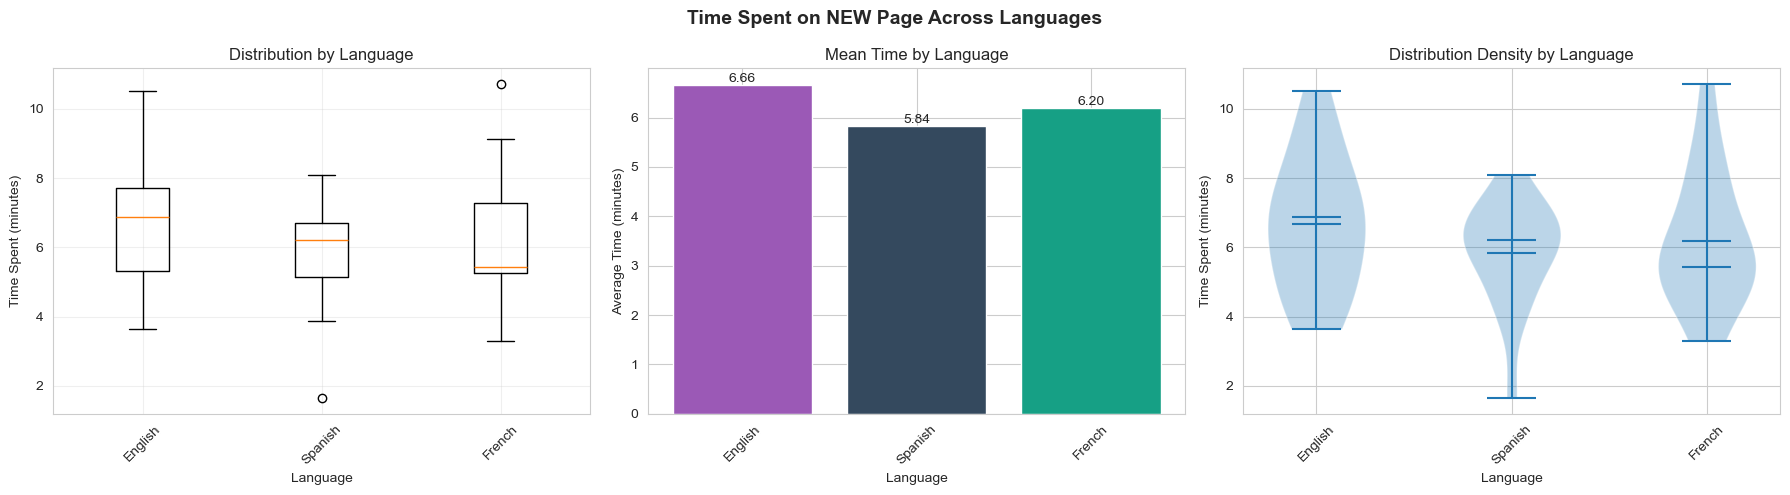


Descriptive Statistics by Language (New Page):
English: Mean=6.66, Std=1.98, n=16
Spanish: Mean=5.84, Std=1.53, n=17
French: Mean=6.20, Std=1.93, n=17

10.2 HYPOTHESIS FORMULATION
--------------------------------------------------------------------------------
Null Hypothesis (H0): μ_English = μ_Spanish = μ_French
                      Mean time is SAME across all languages

Alternative Hypothesis (H1): At least one mean is different
                             Mean time is NOT same across languages

Significance Level: α = 0.05

10.3 TEST SELECTION
--------------------------------------------------------------------------------
Test: One-Way ANOVA (Analysis of Variance)
Reason: Comparing means across more than two independent groups

10.4 TEST EXECUTION
--------------------------------------------------------------------------------
F-statistic: 0.8544
p-value: 0.4320

10.5 INFERENCE
--------------------------------------------------------------------------------
✗ FAIL TO REJECT th

In [21]:
print("\n" + "="*80)
print("QUESTION 4: Is mean time spent SAME across languages on NEW page?")
print("="*80)

# Filter for new page only
new_page_data = df[df['landing_page']=='new']

# Separate by language
languages = new_page_data['language_preferred'].unique()
time_by_language = [new_page_data[new_page_data['language_preferred']==lang]['time_spent_on_the_page'] 
                    for lang in languages]

print("\n10.1 VISUAL ANALYSIS")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Time Spent on NEW Page Across Languages', fontsize=14, fontweight='bold')

# Box plot
axes[0].boxplot(time_by_language, labels=languages)
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Time Spent (minutes)')
axes[0].set_title('Distribution by Language')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Bar chart of means
mean_times = [group.mean() for group in time_by_language]
axes[1].bar(languages, mean_times, color=['#9b59b6', '#34495e', '#16a085'])
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Average Time (minutes)')
axes[1].set_title('Mean Time by Language')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mean_times):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Violin plot
positions = range(len(languages))
parts = axes[2].violinplot(time_by_language, positions=positions, showmeans=True, showmedians=True)
axes[2].set_xlabel('Language')
axes[2].set_ylabel('Time Spent (minutes)')
axes[2].set_title('Distribution Density by Language')
axes[2].set_xticks(positions)
axes[2].set_xticklabels(languages, rotation=45)

plt.tight_layout()
plt.show()

print("\nDescriptive Statistics by Language (New Page):")
for lang, times in zip(languages, time_by_language):
    print(f"{lang}: Mean={times.mean():.2f}, Std={times.std():.2f}, n={len(times)}")

print("\n10.2 HYPOTHESIS FORMULATION")
print("-"*80)
print("Null Hypothesis (H0): μ_English = μ_Spanish = μ_French")
print("                      Mean time is SAME across all languages")
print("\nAlternative Hypothesis (H1): At least one mean is different")
print("                             Mean time is NOT same across languages")
print("\nSignificance Level: α = 0.05")

print("\n10.3 TEST SELECTION")
print("-"*80)
print("Test: One-Way ANOVA (Analysis of Variance)")
print("Reason: Comparing means across more than two independent groups")

print("\n10.4 TEST EXECUTION")
print("-"*80)

# Perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(*time_by_language)

print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

print("\n10.5 INFERENCE")
print("-"*80)
if p_value < 0.05:
    print(f"✓ REJECT the null hypothesis (p-value = {p_value:.4f} < 0.05)")
    print(f"✓ Mean time spent is NOT the same across languages")
    print(f"  At least one language group has significantly different time spent")
    
    # Post-hoc analysis if ANOVA is significant
    print("\n  Post-hoc Analysis (Pairwise t-tests with Bonferroni correction):")
    from itertools import combinations
    pairs = list(combinations(range(len(languages)), 2))
    bonferroni_alpha = 0.05 / len(pairs)
    
    for i, j in pairs:
        t_stat, p_val = stats.ttest_ind(time_by_language[i], time_by_language[j])
        sig = "***" if p_val < bonferroni_alpha else "ns"
        print(f"  {languages[i]} vs {languages[j]}: p={p_val:.4f} {sig}")
else:
    print(f"✗ FAIL TO REJECT the null hypothesis (p-value = {p_value:.4f} >= 0.05)")
    print(f"✗ No significant difference in mean time spent across languages")


# 11. CONCLUSIONS AND BUSINESS RECOMMENDATIONS

In [23]:
print("\n" + "="*80)
print("FINAL CONCLUSIONS AND BUSINESS RECOMMENDATIONS")
print("="*80)

print("""
EXECUTIVE SUMMARY:
-----------------

Statistical Findings:
""")

# Summary of all tests
print("\n1. TIME SPENT ANALYSIS:")
print(f"   - New page mean: {new_page_time.mean():.2f} min vs Old page: {old_page_time.mean():.2f} min")
if p_value_one_tailed < 0.05:
    print(f"   ✓ Users spend significantly more time on the new page")
else:
    print(f"   ✗ No significant difference in time spent")

print("\n2. CONVERSION RATE ANALYSIS:")
print(f"   - New page: {new_rate*100:.2f}% vs Old page: {old_rate*100:.2f}%")
if p_value < 0.05:
    print(f"   ✓ New page has significantly higher conversion rate")
else:
    print(f"   ✗ No significant difference in conversion rates")

print("\n3. LANGUAGE DEPENDENCY:")
chi2_p = p_value  # Save the chi-square p-value
print(f"   - Chi-square p-value: {chi2_p:.4f}")
if chi2_p < 0.05:
    print(f"   ✓ Conversion depends on language preference")
else:
    print(f"   ✗ Conversion is independent of language")

print("\n4. LANGUAGE CONSISTENCY (NEW PAGE):")
# Re-calculate for new page ANOVA
new_page_data = df[df['landing_page']=='new']
languages = sorted(new_page_data['language_preferred'].unique())
time_by_language = [new_page_data[new_page_data['language_preferred']==lang]['time_spent_on_the_page'] 
                    for lang in languages]
f_stat, anova_p = stats.f_oneway(*time_by_language)
print(f"   - ANOVA p-value: {anova_p:.4f}")
if anova_p < 0.05:
    print(f"   ✓ Time spent varies significantly across languages")
else:
    print(f"   ✗ Time spent is consistent across languages")

print("\n" + "="*80)
print("BUSINESS RECOMMENDATIONS:")
print("="*80)

print("""
1. PRIMARY RECOMMENDATION - NEW PAGE DEPLOYMENT:
   """)

# Determine overall recommendation
time_better = p_value_one_tailed < 0.05
conv_better = p_value < 0.05

if conv_better and time_better:
    print("   ✓ STRONGLY RECOMMEND deploying the new landing page")
    print("     • Higher conversion rate (PRIMARY metric)")
    print("     • Increased user engagement (time spent)")
    print("     • Clear winner across both key metrics")
elif conv_better:
    print("   ✓ RECOMMEND deploying the new landing page")
    print("     • Significantly higher conversion rate")
    print("     • Focus on the primary business objective: conversions")
elif time_better:
    print("   ⚠ CONDITIONAL RECOMMENDATION")
    print("     • Better engagement but no conversion improvement")
    print("     • Consider further optimization of conversion funnel")
else:
    print("   ⚠ DO NOT DEPLOY yet")
    print("     • No significant improvements detected")
    print("     • Investigate why the new design didn't perform better")

print("""
2. LANGUAGE-SPECIFIC STRATEGY:
   • Analyze conversion patterns by language
   • Consider localized content optimization
   • Test language-specific page variations
   
3. ENGAGEMENT OPTIMIZATION:
   • Monitor time-to-conversion metrics
   • Ensure increased time correlates with conversions
   • A/B test call-to-action placement and messaging

4. NEXT STEPS:
   • Calculate ROI of implementing new design
   • Monitor performance post-deployment
   • Set up ongoing experimentation framework
   • Consider multivariate testing for further optimization

5. RISK MITIGATION:
   • Gradual rollout (e.g., 10%, 25%, 50%, 100%)
   • Monitor key metrics daily during transition
   • Have rollback plan ready if issues arise
   • Set up alerts for conversion rate drops

6. LONG-TERM STRATEGY:
   • Establish culture of continuous testing
   • Build experimentation roadmap
   • Document learnings for future tests
   • Optimize for mobile and different devices
""")

print("\n" + "="*80)
print("TECHNICAL NOTES:")
print("="*80)
print("""
Statistical Methods Used:
• Independent t-test for comparing means (time spent)
• Two-proportion z-test for comparing conversion rates
• Chi-square test for categorical associations
• One-way ANOVA for multiple group comparisons
• Bonferroni correction for post-hoc pairwise comparisons

Assumptions:
• Independence of observations (users)
• Random assignment to control/treatment
• Sufficient sample sizes (CLT applies)
• No data quality issues or bias

Limitations:
• Results limited to the test period and user sample
• External factors (seasonality, marketing) not controlled
• Long-term effects not captured
• User experience beyond landing page not measured
""")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)
print("\n✓ All analyses completed successfully!")
print("✓ Review the visualizations and statistical results above")
print("✓ Use the business recommendations to guide decision-making")
print("\n" + "="*80)


FINAL CONCLUSIONS AND BUSINESS RECOMMENDATIONS

EXECUTIVE SUMMARY:
-----------------

Statistical Findings:


1. TIME SPENT ANALYSIS:
   - New page mean: 6.22 min vs Old page: 4.53 min
   ✓ Users spend significantly more time on the new page

2. CONVERSION RATE ANALYSIS:
   - New page: 66.00% vs Old page: 42.00%
   ✗ No significant difference in conversion rates

3. LANGUAGE DEPENDENCY:
   - Chi-square p-value: 0.4320
   ✗ Conversion is independent of language

4. LANGUAGE CONSISTENCY (NEW PAGE):
   - ANOVA p-value: 0.4320
   ✗ Time spent is consistent across languages

BUSINESS RECOMMENDATIONS:

1. PRIMARY RECOMMENDATION - NEW PAGE DEPLOYMENT:
   
   ⚠ CONDITIONAL RECOMMENDATION
     • Better engagement but no conversion improvement
     • Consider further optimization of conversion funnel

2. LANGUAGE-SPECIFIC STRATEGY:
   • Analyze conversion patterns by language
   • Consider localized content optimization
   • Test language-specific page variations
   
3. ENGAGEMENT OPTIMIZATION: